# Chapter 01 - Exploratory Data Analysis
## Enhanced Visual + Theory Edition

## Objectives
Understand structured data, location, variability, distributions, categorical analysis, correlation, and multivariable exploration. Every section includes visuals.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import trim_mean, gaussian_kde
sns.set_theme(style='whitegrid')
np.random.seed(42)
df=pd.DataFrame({
 'Age':np.random.randint(18,60,300),
 'Salary':np.random.normal(8000,2500,300).clip(1500,None),
 'Experience':np.random.randint(0,25,300),
 'Department':np.random.choice(['HR','IT','Finance','Sales'],300),
 'Purchased':np.random.choice([0,1],300,p=[0.6,0.4])
})
df['Salary']=df['Salary'].round(0)
df.head()

,Age,Salary,Experience,Department,Purchased
0,56,10125.0,23,IT,1
1,46,8986.0,21,HR,0
2,32,7988.0,13,HR,1
3,25,4073.0,22,IT,0
4,38,11700.0,13,IT,0


## 1. Structured Data Concepts
- **Numerical:** continuous/discrete values.
- **Categorical:** labels/classes.
- **Binary:** two classes.
- **Ordinal:** ordered categories.
EDA starts by identifying variable types because plots and models depend on them.

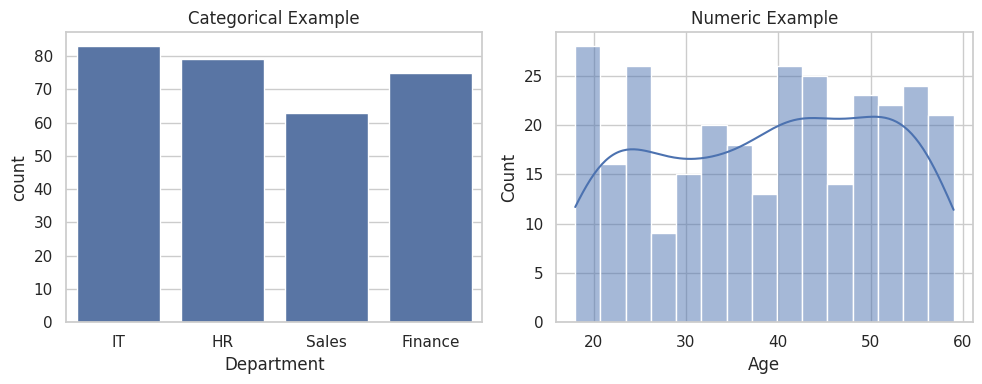

In [2]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); sns.countplot(x='Department',data=df); plt.title('Categorical Example')
plt.subplot(1,2,2); sns.histplot(df['Age'],bins=15,kde=True); plt.title('Numeric Example')
plt.tight_layout(); plt.show()

## 2. Estimates of Location
Central tendency helps summarize where data clusters.
- **Mean:** sensitive to outliers.
- **Median:** robust.
- **Trimmed Mean:** compromise between mean and median.

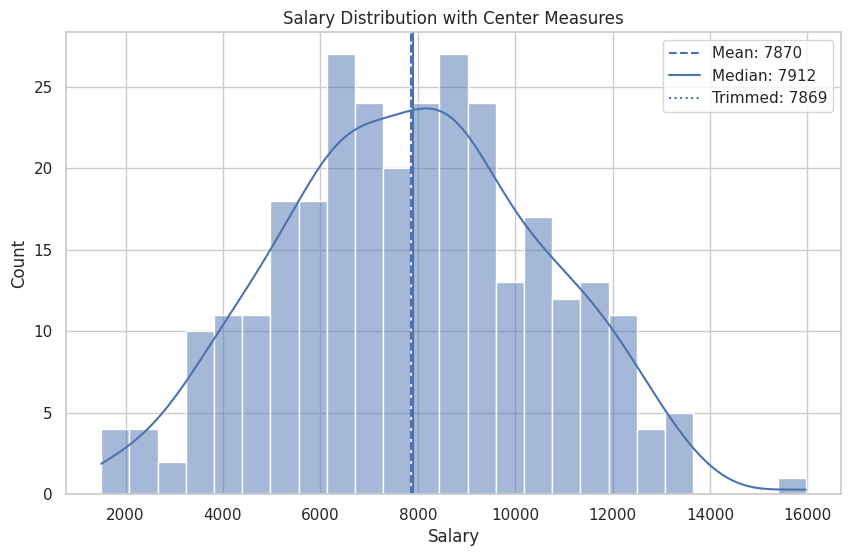

{'mean': np.float64(7869.616666666667), 'median': 7912.5, 'trimmed_mean': np.float64(7869.283333333334)}


In [3]:
x=df['Salary']
mean_v=x.mean(); med=x.median(); trim=trim_mean(x,0.1)
plt.figure(figsize=(10,6))
sns.histplot(x,bins=25,kde=True)
for v,l,s in [(mean_v,'Mean','--'),(med,'Median','-'),(trim,'Trimmed',':')]:
    plt.axvline(v,linestyle=s,label=f'{l}: {v:.0f}')
plt.legend(); plt.title('Salary Distribution with Center Measures'); plt.show()
print({'mean':mean_v,'median':med,'trimmed_mean':trim})

## 3. Variability
Spread matters as much as center.
- Standard deviation measures average dispersion.
- IQR is robust.
- Range can be distorted by extremes.

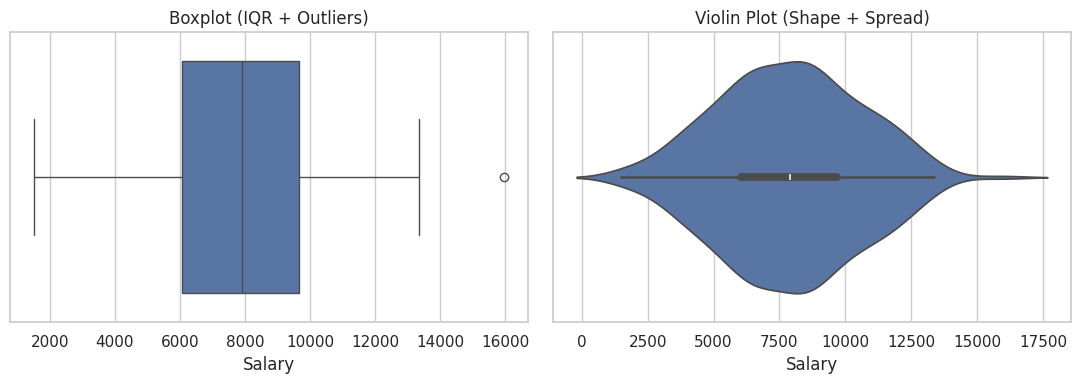

{'std': 2656.630290057133, 'iqr': np.float64(3609.25), 'range': 14468.0}


In [4]:
std=x.std(); iqr=x.quantile(.75)-x.quantile(.25)
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(x=x,ax=ax[0]); ax[0].set_title('Boxplot (IQR + Outliers)')
sns.violinplot(x=x,ax=ax[1]); ax[1].set_title('Violin Plot (Shape + Spread)')
plt.tight_layout(); plt.show()
print({'std':std,'iqr':iqr,'range':x.max()-x.min()})

## 4. Distribution Shape
Important concepts:
- Symmetric vs skewed
- Multimodal patterns
- Heavy tails
- Outliers

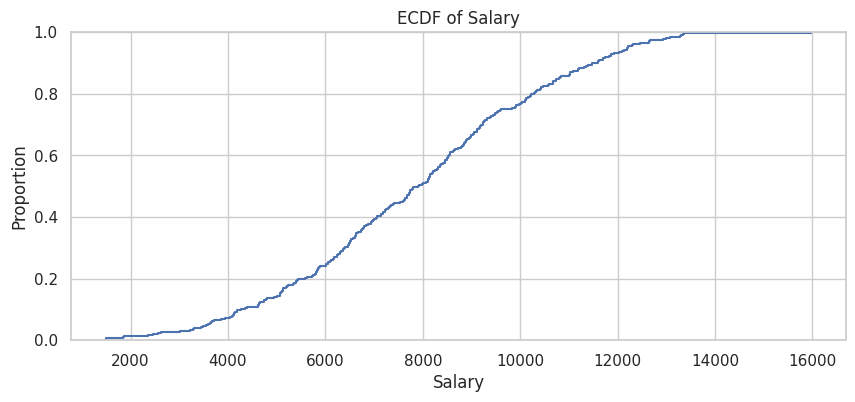

In [5]:
plt.figure(figsize=(10,4))
sns.ecdfplot(x); plt.title('ECDF of Salary'); plt.xlabel('Salary'); plt.show()

## 5. Binary & Categorical Analysis
Class balance matters for ML. Imbalanced classes can mislead accuracy.

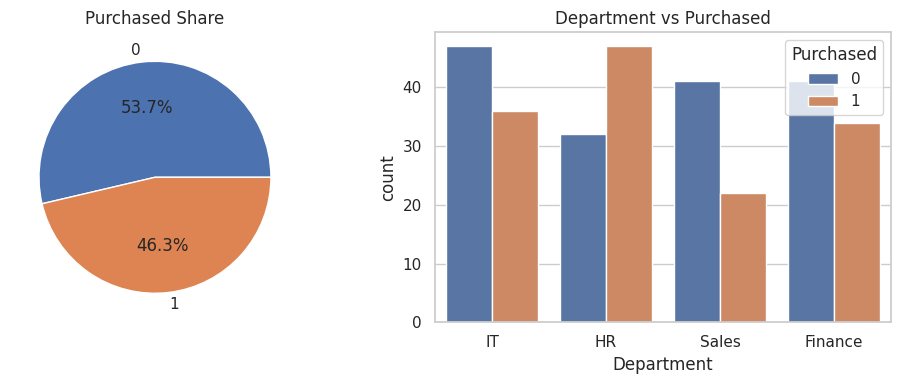

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
df['Purchased'].value_counts().plot.pie(autopct='%1.1f%%',ax=ax[0]); ax[0].set_ylabel(''); ax[0].set_title('Purchased Share')
sns.countplot(x='Department',hue='Purchased',data=df,ax=ax[1]); ax[1].set_title('Department vs Purchased')
plt.tight_layout(); plt.show()

## 6. Correlation
Measures linear relationship (-1 to +1). Correlation is not causation.

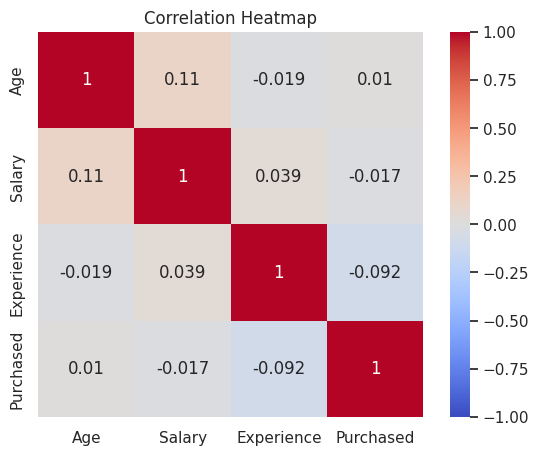

In [7]:
corr=df[['Age','Salary','Experience','Purchased']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,square=True)
plt.title('Correlation Heatmap'); plt.show()

## 7. Two or More Variables
Use scatterplots and grouped summaries to detect trends, clusters, nonlinearity.

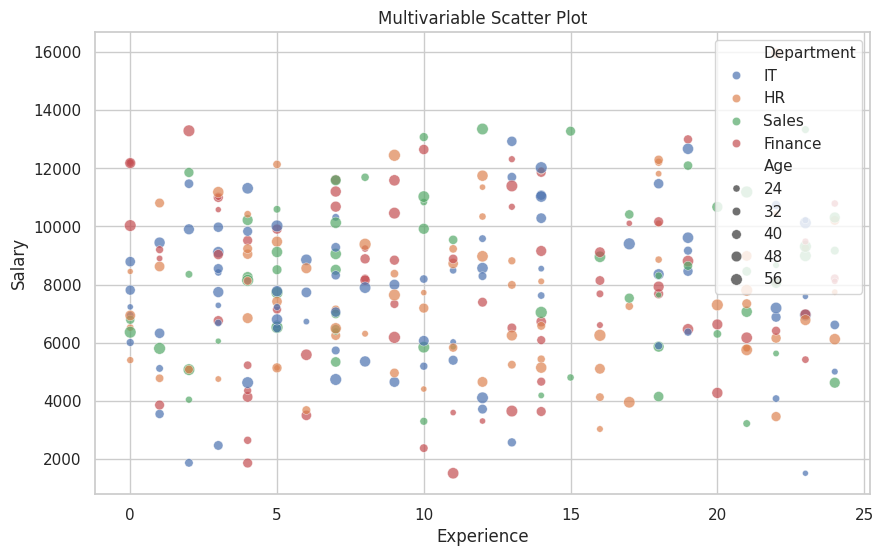

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Experience',y='Salary',hue='Department',size='Age',alpha=.7)
plt.title('Multivariable Scatter Plot'); plt.show()

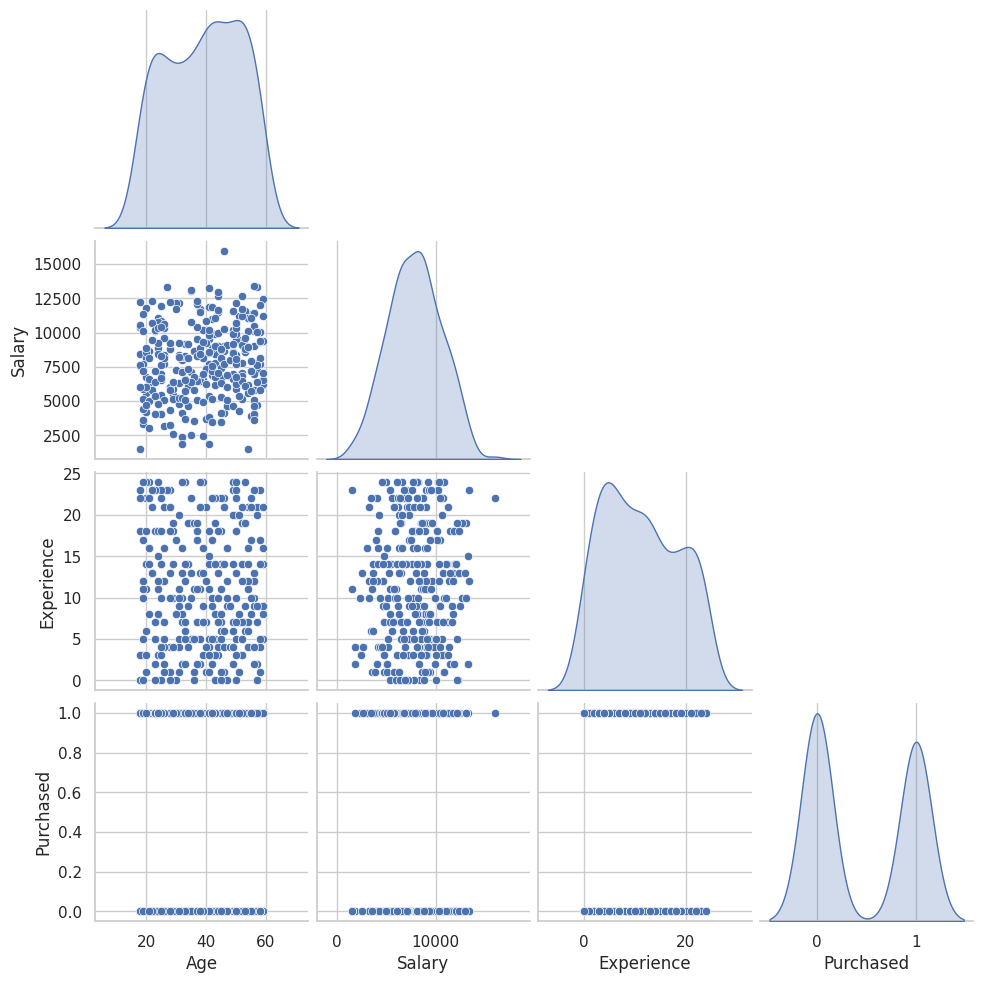

In [9]:
sns.pairplot(df[['Age','Salary','Experience','Purchased']],corner=True,diag_kind='kde')
plt.show()

## Key Takeaways
1. EDA is mandatory before modeling.
2. Use median/IQR when outliers exist.
3. Visuals reveal what summary tables miss.
4. Check class balance and relationships.
5. Better EDA often beats more complex models.